# Modelagem e Simulação Multifísica - Aula 05

## Trabalho Computacional 01 - Operação em malha fechada

Para ilustrar a operação em malha fechada, iremos usar os parâmetros disponíveis no modelo DELT-UFMG. Como o modelo apresenta apenas os parâmetros mecânicos, os parâmetros elétricos $Bl(i,x)$ e $L(x)$ serão extrapolados a partir da constante $k$. Adicionalmente, será considerada uma resistência $R=1\Omega$.

### Modelo DELT - UFMG

In [2]:
import numpy as np

# Parameters (EC5)
m = 0.022 # (Kg)
g = 9.81 #(m/s^2)
kfm = 1.8632e-5 #(Nm^2/A^2) 
Kl = 0.0000415
b = 0.4082238
x0 = 0.01 #(m)
fm0 = m*g
i0 = np.sqrt((fm0*x0**2)/kfm) #(A)

print(i0)

1.076257290456036


Parâmetros variáveis com a posição:

In [3]:
# Magnetic force fm
def fm(i,x):
    return kfm*((i*i)/(x*x))
# Force Factor
def Bl(i,x):
     return fm(i,x)/i #(N/A)
# Inductance
def L(x):
     return Kl/x + b#(H)
# Resistance
R = 13.5 #(Ohm)
u0 = R*i0

### O controlador PID
O controlador utilizado será um sistema linear que tem como entrada o erro
entre a posição atual e a posição desejada

\begin{equation}
e(t) = x(t) - x_0
\end{equation}

A saída do controlador é a variação $\Delta u(t)$ na
tensão de entrada que corrige a tensão $u_0$ (tensão do ponto de equilíbrio) para forçar a estabilidade do sistema, matematicamente:

\begin{equation}
u(t) = u_0 + \Delta u(t),
\end{equation} 
\begin{equation}
\Delta u(t) = K_p e(t) + K_i E(t) + K_d \dot e(t),
\end{equation} 

onde $\dot E(t) = e(t)$. Esse tipo de controlador é conhecido como PID (Proporcional, Integral, Derivativo), porque consiste de três termos: o primeiro é um termo proporcional
ao erro, o segundo termo corresponde à uma integral do erro, e o terceiro termo aproxima uma derivada do erro. Não é objetivo dessa disciplina encontrar os parâmetros ótimos do controlador. Assumiremos apenas que os ganhos são parâmetros constantes conhecidos.

In [4]:
# PID parameters
Kp = 600 
Ki = 1e11
Kd = 34000

### Representação em espaço de estados
Adicionando a equação do controlador na representação por espaço de estados da seção 3, o sistema pode ser reescrito como: 

\begin{eqnarray}
\dot i &=& - \frac{R}{L(x)}i - \frac{Bl(x,i)}{L(x)} v + \frac{u_0+\Delta u(e,E,v)}{L(x)}\\
\dot x &=& v \\
\dot v &=& g - \frac{f_m(x,i)}{m} \\
\dot E &=& e \\
\end{eqnarray}

onde

\begin{eqnarray}
e &=& x-x_0\\
\dot e &=& v \\
\Delta u &=& K_p e(t) + K_i E(t) + K_d v\\
\end{eqnarray}


In [5]:
# State space representation in vector form
# dy = y´ = function(y,t)
# y = [i,x,v,E]

def odePID(t,y):
    i,x,v,E = y
    e = x-x0
    delta_u = Kp*e + Kd*v +Ki*E
    
    #di/dt
    di = -R/L(x)*i-Bl(i,x)/L(x)*v+(u0+delta_u)/L(x)
    #dx/dt
    dx = v
    #dv/dt
    dv = g - fm(i,x)/m 
    #dE/dt
    dE = e
    
    return [di, dx, dv, dE]

### Resolvendo o sistema


In [6]:
from scipy.integrate import solve_ivp

# Initial conditions
# y = [i,x,v,E]
y_0 = [i0,x0,0.0,0.0]
# Time span
t_0 = 0.0
t_end = 5 #(s) 

sol = solve_ivp(odePID, [t_0, t_end],y_0)

print(sol)

  message: Required step size is less than spacing between numbers.
  success: False
   status: -1
        t: [ 0.000e+00  1.000e-04 ...  1.340e-01  1.340e-01]
        y: [[ 1.076e+00  1.076e+00 ... -3.956e+04 -4.705e+04]
            [ 1.000e-02  1.000e-02 ...  1.741e-08  1.183e-08]
            [ 0.000e+00  0.000e+00 ... -8.960e+06 -1.293e+07]
            [ 0.000e+00  0.000e+00 ... -6.270e-07 -6.270e-07]]
      sol: None
 t_events: None
 y_events: None
     nfev: 650
     njev: 0
      nlu: 0


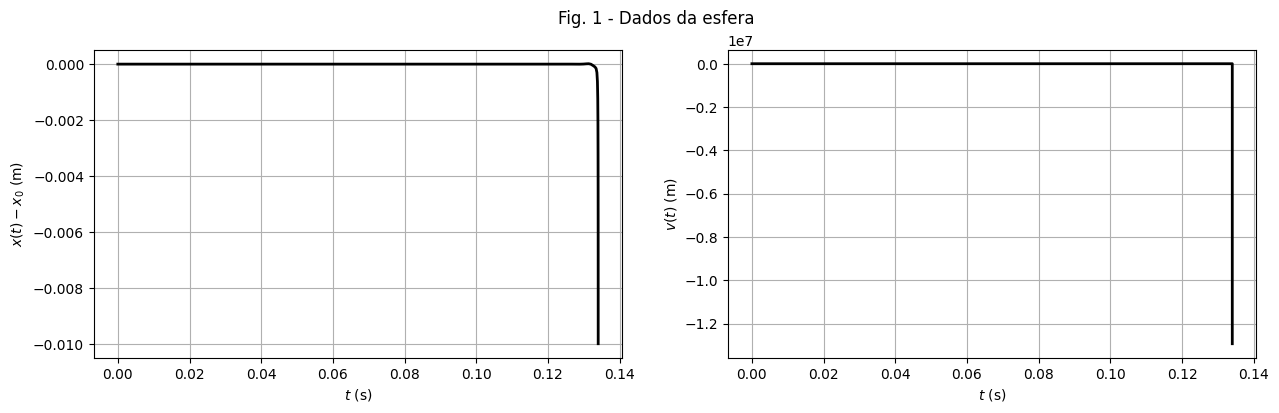

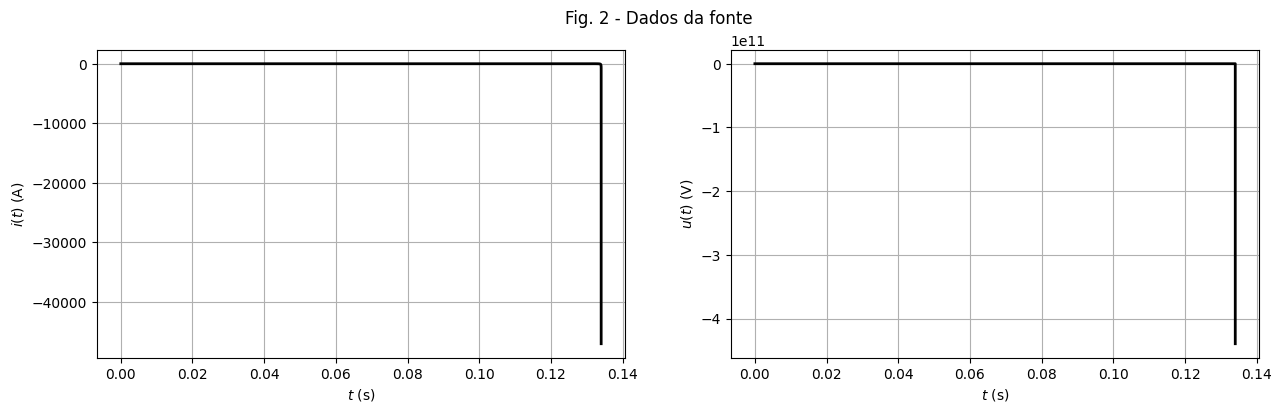

In [7]:
import matplotlib.pyplot as plt

# --- Position plot --- 
fig = plt.figure(figsize=(15,4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[1,:]-x0, 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$x(t)-x_0$ (m)');
fig.suptitle('Fig. 1 - Dados da esfera');

plt.subplot(1, 2, 2)
plt.plot(sol.t, sol.y[2,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$v(t)$ (m)');

# --- Source plot ---
fig = plt.figure(figsize=(15,4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$i(t)$ (A)');
fig.suptitle('Fig. 2 - Dados da fonte');

# y = [i,x,v,E]
uf = Kp*(sol.y[1,:]-x0) + Ki*sol.y[3,:] + Kd*sol.y[2,:]+u0
plt.subplot(1, 2, 2)
plt.plot(sol.t, uf, 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$u(t)$ (V)');
#fig.suptitle('Fig. 1 - Posição da esfera');


